# Examples Paper 1

In [2]:
import numpy as np
import scipy.special as special
import sounddevice as sd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'font.size': 12,'font.family':'serif'})


In [6]:
%matplotlib widget

## Q2

In [7]:
f1 = 440
a = 0.42
r = 5e-4
rho=7800
E = 200e9

In [8]:
P=(2*440*0.42)**2*7800*np.pi*(5e-4)**2
print(P)

836.8515197363189


In [9]:
I = np.pi*r**4 / 4

n = (P/E/I*(a/np.pi)**2)**(1/3)
print(n)

11.506655655454523


In [10]:
# brute force method
n = np.arange(20)

In [11]:
m = rho*np.pi*r**2
wn = n*np.pi/a * np.sqrt(P/m)
wn_new = wn*(1+0.5*(n*np.pi/a)**2*E*I/P)

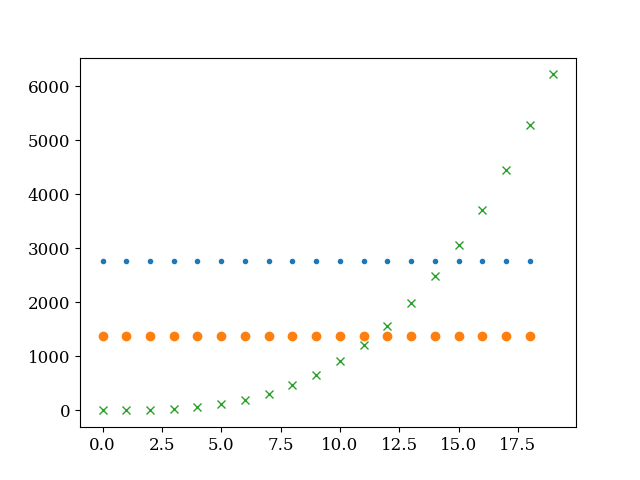

In [12]:
plt.plot(np.diff(wn),'.')
plt.plot(np.diff(wn)/2,'o')
plt.plot(wn_new-wn,'x')

In [43]:
T = 3
fs=44100
t = np.arange(0,T,1/fs)
N_harmonics = 30

n = np.arange(N_harmonics)
wn = n*np.pi/a * np.sqrt(P/m)
wn_new = wn*(1+0.5*(n*np.pi/a)**2*E*I/P)

y0 = 0*t
y1 = 0*t
for n in np.arange(N_harmonics):
    y0 += np.sin(wn[n]*t)
    y1 += np.sin(wn_new[n]*t)

In [44]:
y0 = y0/np.max(abs(y0)) * np.exp(-t/1)
y1 = y1/np.max(abs(y1)) * np.exp(-t/1)

In [61]:
sd.play(y0,fs)

In [60]:
sd.play(y1,fs)

## Q8

In [74]:
e = np.linspace(0,1,1000)
imEI = e*(1+1/(1+e)**2)

<IPython.core.display.Javascript object>


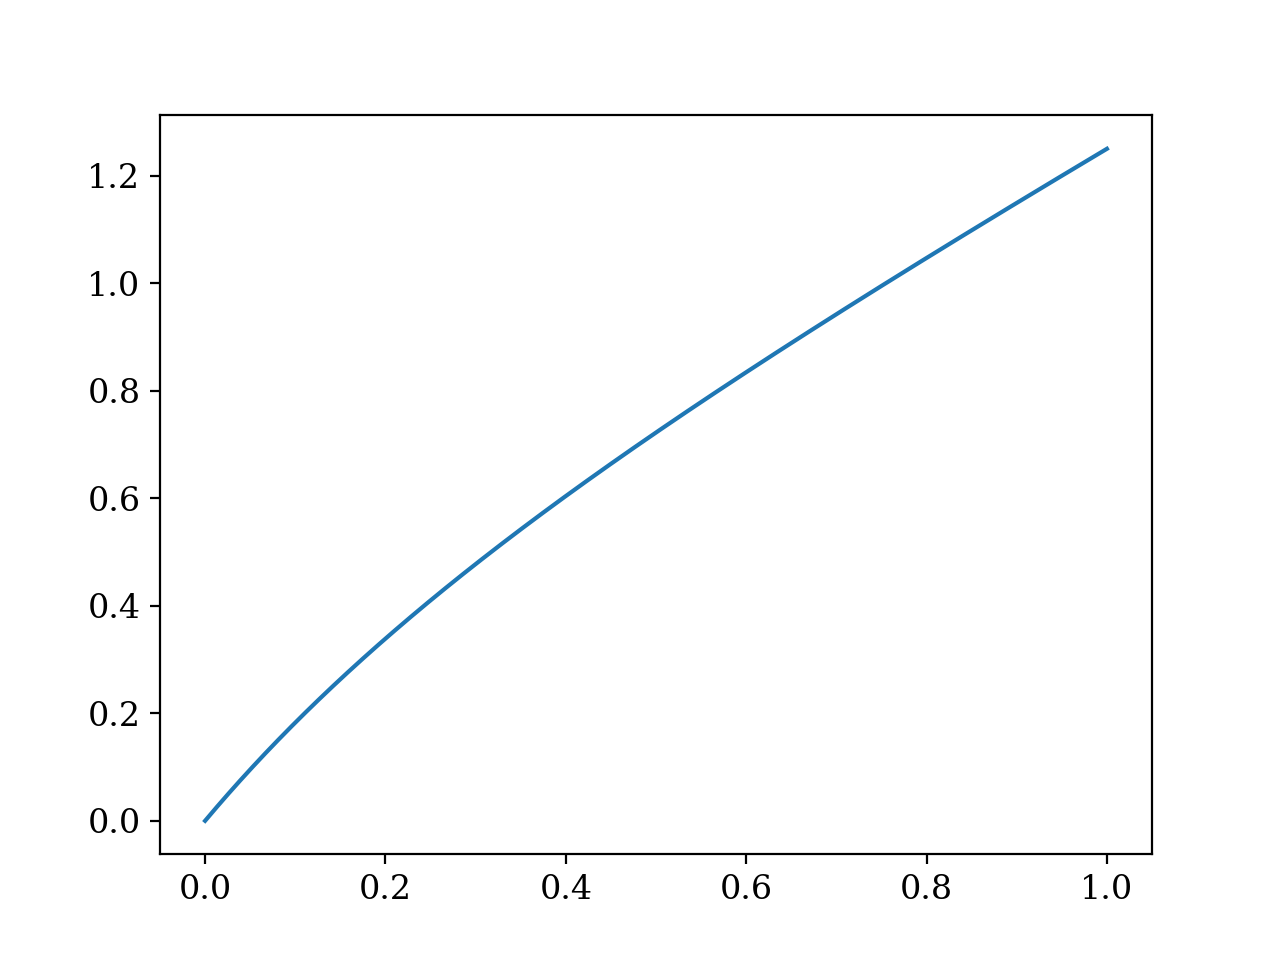

In [75]:
plt.plot(e,imEI)